# Fasion MNIST

In [6]:
from tensorflow.keras.datasets.fashion_mnist import load_data

# Fashion-MNIST 데이터를 다운받습니다.
(x_train, y_train), (x_test, y_test) = load_data()
print(x_train.shape, x_test.shape)

(60000, 28, 28) (10000, 28, 28)


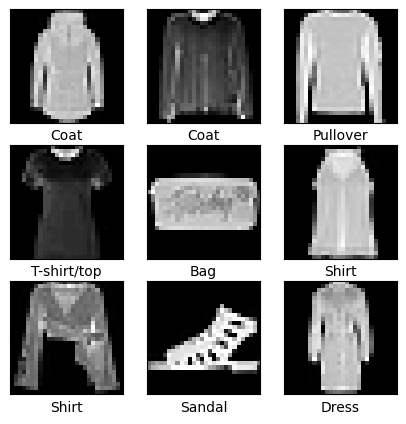

In [7]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(777)

# Fashion-MNIST의 레이블에 해당하는 품목입니다.
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

sample_size = 9
# 0 ~ 59999의 범위에서 무작위로 9개의 정수를 뽑습니다.
random_idx = np.random.randint(60000, size=sample_size)

plt.figure(figsize = (5, 5))
for i, idx in enumerate(random_idx):
    plt.subplot(3, 3, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[idx], cmap = 'gray')
    plt.xlabel(class_names[y_train[idx]])

plt.show()

# 데이터 전처리 및 Validatin DataSet 생성

In [8]:
# 클래스 이름이 이미 숫자로 인코딩 되어있음
print(y_train[:10])

# 값의 범위를 0 ~ 1로 만들어줍니다.(정규화)
x_train = x_train / 255
x_test = x_test / 255

[9 0 0 3 0 2 7 2 5 5]


In [9]:
from tensorflow.keras.utils import to_categorical

# 각 데이터의 레이블을 원핫-인코딩 진행
y_train_categ = to_categorical(y_train)
y_test_catege = to_categorical(y_test)

print(y_train_categ[:10])
print(y_test_catege[:10])

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]


In [10]:
# 검증 데이터 세트를 만듭니다.
from sklearn.model_selection import train_test_split

# 훈련/테스트 데이터를 0.7/0.3의 비율로 분리합니다.
x_train_categ, x_val_categ, y_train_categ, y_val_categ = train_test_split(x_train, y_train_categ,
                                                  test_size = 0.3, random_state = 777)

# 모델 비교

## 첫번째 모델 (원핫 인코딩 데이터)

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

first_categ_model = Sequential()

# 입력 데이터의 형태를 꼭 명시해야 합니다.
first_categ_model.add(Flatten(input_shape = (28, 28))) # (28, 28) -> .(28 * 28)
first_categ_model.add(Dense(64, activation = 'relu')) # 64개의 출력을 가지는 Dense 층
first_categ_model.add(Dense(32, activation = 'relu')) # 32개의 출력을 가지는 Dense 층
first_categ_model.add(Dense(10, activation = 'softmax')) # 10개의 출력을 가지는 신경망

first_categ_model.compile(optimizer='adam', # 옵티마이저 : Adam
              loss = 'categorical_crossentropy', # 손실 함수 : categorical_crossentropy
              metrics=['acc']) # 모니터링 할 평가지표 : acc

first_categ_history = first_categ_model.fit(x_train_categ, y_train_categ,
                                            epochs = 30,
                                            batch_size = 128,
                                            validation_data = (x_val_categ, y_val_categ))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - acc: 0.7580 - loss: 0.6954 - val_acc: 0.8415 - val_loss: 0.4572
Epoch 2/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8451 - loss: 0.4393 - val_acc: 0.8620 - val_loss: 0.4036
Epoch 3/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8559 - loss: 0.4043 - val_acc: 0.8628 - val_loss: 0.3939
Epoch 4/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8677 - loss: 0.3729 - val_acc: 0.8622 - val_loss: 0.3910
Epoch 5/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8717 - loss: 0.3542 - val_acc: 0.8692 - val_loss: 0.3734
Epoch 6/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.8802 - loss: 0.3362 - val_acc: 0.8757 - val_loss: 0.3496
Epoch 7/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8822 - loss: 0.3279 - val_acc: 0.8771 - val_loss: 0.3427
Epoch 8/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8865 - loss: 0.3150 - val_acc: 0.8763 - val_loss: 0.3544
Epoch 9/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - a

## 두번째 모델 : 층이 더 깊음

In [12]:
second_model = Sequential()

# 입력 데이터의 형태를 꼭 명시해야 합니다.
second_model.add(Flatten(input_shape = (28, 28))) # (28, 28) -> .(28 * 28)
second_model.add(Dense(64, activation = 'relu')) # 64개의 출력을 가지는 Dense 층
second_model.add(Dense(32, activation = 'relu')) # 32개의 출력을 가지는 Dense 층
second_model.add(Dense(32, activation = 'relu')) # 32개의 출력을 가지는 Dense 층
second_model.add(Dense(10, activation = 'softmax')) # 10개의 출력을 가지는 신경망

second_model.compile(optimizer='adam', # 옵티마이저 : Adam
              loss = 'sparse_categorical_crossentropy', # 손실 함수: 숫자레이블
              metrics=['acc']) # 모니터링 할 평가지표 : acc

second_history = second_model.fit(x_train, y_train,
                                  epochs = 30,
                                  batch_size = 128,
                                  validation_split=0.3)

Epoch 1/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - acc: 0.7656 - loss: 0.6849 - val_acc: 0.8342 - val_loss: 0.4743
Epoch 2/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.8390 - loss: 0.4530 - val_acc: 0.8492 - val_loss: 0.4262
Epoch 3/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8566 - loss: 0.4046 - val_acc: 0.8526 - val_loss: 0.4144
Epoch 4/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8628 - loss: 0.3826 - val_acc: 0.8638 - val_loss: 0.3809
Epoch 5/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8716 - loss: 0.3584 - val_acc: 0.8546 - val_loss: 0.4006
Epoch 6/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8775 - loss: 0.3401 - val_acc: 0.8742 - val_loss: 0.3552
Epoch 7/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8820 - loss: 0.3279 - val_acc: 0.8763 - val_loss: 0.3497
Epoch 8/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8852 - loss: 0.3148 - val_acc: 0.8774 - val_loss: 0.3430
Epoch 9/30
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - ac

# 학습 과정 그려보기

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def draw_loss_acc(history_1, history_2, epochs):
    his_dict_1 = history_1.history
    his_dict_2 = history_2.history
    keys = list(his_dict_1.keys())

    epochs = range(1, epochs)
    fig = plt.figure(figsize = (10, 10))
    ax = fig.add_subplot(1, 1, 1)
    # axis 선과 ax의 축 레이블을 제거합니다.
    ax.spines['top']
    ax.spines['bottom']
    ax.spines['left']
    ax.spines['right']
    ax.tick_params(labelcolor='w', top=False, bottom=False, left=False, right=False)

    for i in range(len(his_dict_1)):
        temp_ax = fig.add_subplot(2, 2, i + 1)
        temp = keys[i%2]
        val_temp = keys[(i + 2)%2 + 2]
        temp_history = his_dict_1 if i < 2 else his_dict_2
        temp_ax.plot(epochs, temp_history[temp][1:], color = 'blue', label = 'train_' + temp)
        temp_ax.plot(epochs, temp_history[val_temp][1:], color = 'orange', label = val_temp)
        if(i == 1 or i == 3):
            start, end = temp_ax.get_ylim()
            temp_ax.yaxis.set_ticks(np.arange(np.round(start, 2), end, 0.01))
        temp_ax.legend()
    ax.set_ylabel('loss', size = 20)
    ax.set_xlabel('Epochs', size = 20)
    plt.tight_layout()
    plt.show()

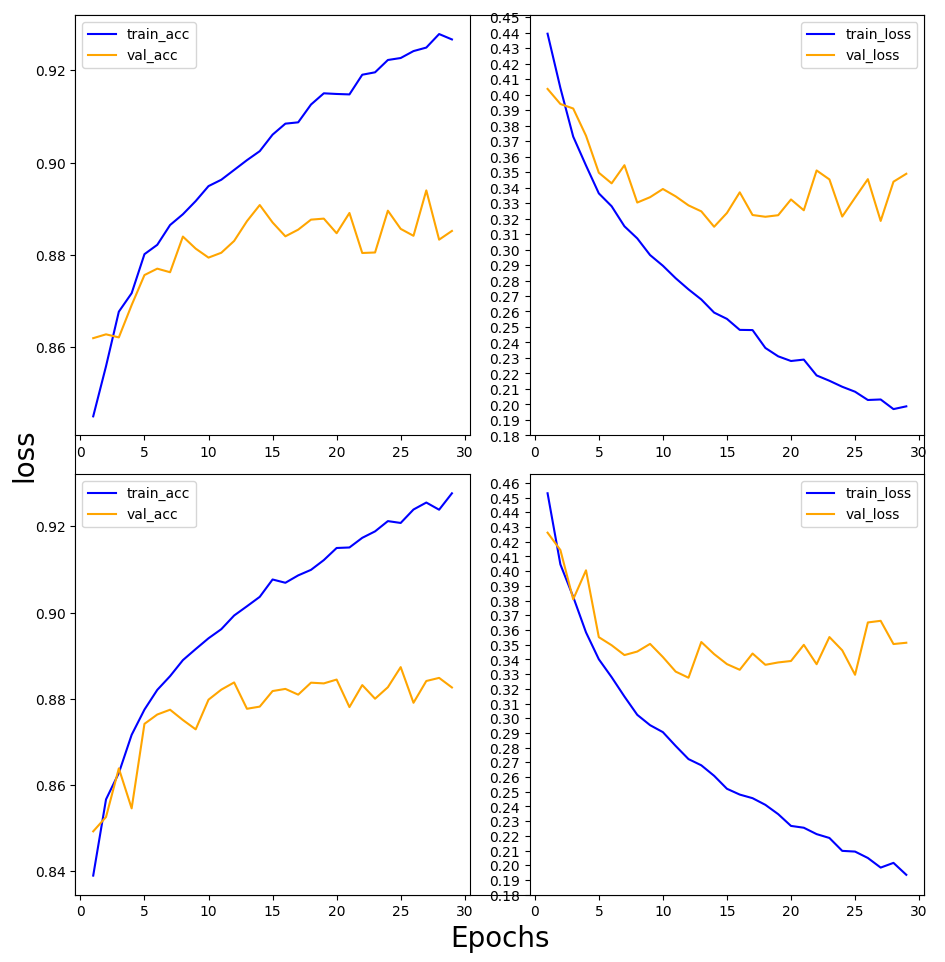

In [14]:
draw_loss_acc(first_categ_history, second_history, 30)

# 모델 평가

In [15]:
first_categ_model.evaluate(x_test, y_test_catege)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.8749 - loss: 0.4001


[0.4001077711582184, 0.8748999834060669]

In [16]:
second_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.8734 - loss: 0.3847


[0.38466739654541016, 0.8733999729156494]

- 모델을 깊게 구성한다고해서 높은 성능이 보장되지는 않는다.
- 모델의 깊이는 데이터에 따라 적합하게 구성해야 한다.
- 다양한 방법으로 데이터셋 및 높은 성능을 보여준 모델을 참조하여 구성한다.